In [1]:
# Realistic example: US real GDP (quarterly) -- single differencing (of log) makes it stationary
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.api import datasets
from statsmodels.tsa.stattools import adfuller
# from caas_jupyter_tools import display_dataframe_to_user

In [2]:
# Load real-world macroeconomic data (US, 1959Q1–2009Q3) from statsmodels
macro = datasets.macrodata.load_pandas().data

# Use real GDP
gdp = macro["realgdp"].astype(float)
dates = pd.period_range(start="1959Q1", periods=len(gdp), freq="Q").to_timestamp()
df = pd.DataFrame({"date": dates, "realgdp": gdp})

In [3]:
df.head()

,date,realgdp
0,1959-01-01,2710.349
1,1959-04-01,2778.801
2,1959-07-01,2775.488
3,1959-10-01,2785.204
4,1960-01-01,2847.699


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 203 entries, 0 to 202
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   date     203 non-null    datetime64[ns]
 1   realgdp  203 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 3.3 KB


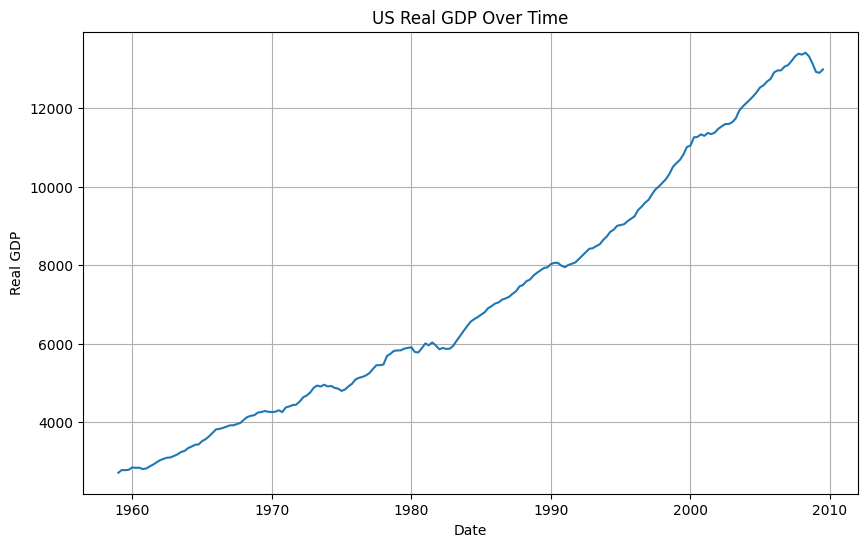

In [5]:
plt.figure(figsize=(10, 6))
plt.plot(df['date'], df['realgdp'])
plt.title('US Real GDP Over Time')
plt.xlabel('Date')
plt.ylabel('Real GDP')
plt.grid(True)
plt.show()

In [6]:
df["log_gdp"] = np.log(df["realgdp"])
df["dlog_gdp"] = df["log_gdp"].diff()  # quarterly growth rate approximation

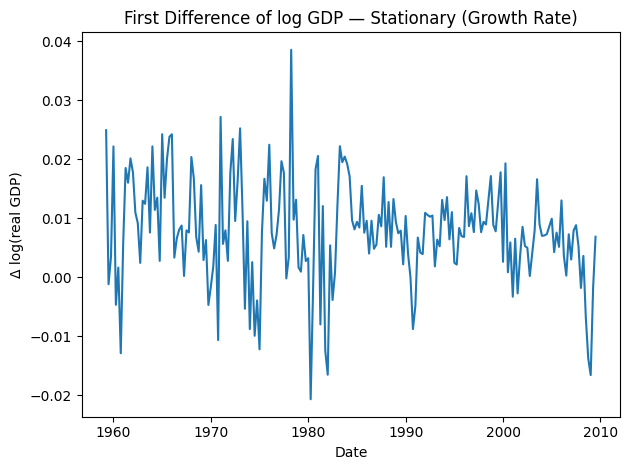

In [7]:

# Plot first difference of log (growth)
plt.figure()
plt.plot(df["date"][1:], df["dlog_gdp"][1:])
plt.title("First Difference of log GDP — Stationary (Growth Rate)")
plt.xlabel("Date")
plt.ylabel("Δ log(real GDP)")
plt.tight_layout()
plt.show()

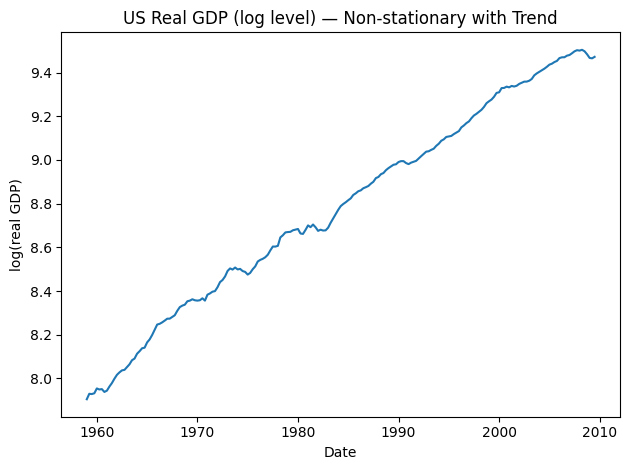

In [8]:

# Plot original level (log)
plt.figure()
plt.plot(df["date"], df["log_gdp"])
plt.title("US Real GDP (log level) — Non-stationary with Trend")
plt.xlabel("Date")
plt.ylabel("log(real GDP)")
plt.tight_layout()
plt.show()

In [9]:
# ADF tests (drop NA for differenced series)
# adf_log = adfuller(df["log_gdp"].dropna())
adf_dlog = adfuller(df["dlog_gdp"].dropna())

In [10]:
# adf_log

In [11]:
adf_dlog

(np.float64(-6.972871347216282),
 np.float64(8.575095844896131e-10),
 1,
 200,
 {'1%': np.float64(-3.463476079125),
  '5%': np.float64(-2.876102355),
  '10%': np.float64(-2.574532225)},
 np.float64(-1261.440139599381))

In [12]:
# Prepare a small text summary of ADF results
results = {
    # "log(real_gdp)": {"ADF Statistic": adf_log[0], "p-value": adf_log[1]},
    "diff(log(real_gdp))": {"ADF Statistic": adf_dlog[0], "p-value": adf_dlog[1]}
}
results

{'diff(log(real_gdp))': {'ADF Statistic': np.float64(-6.972871347216282),
  'p-value': np.float64(8.575095844896131e-10)}}

In [13]:
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# from statsmodels.api import datasets
# from statsmodels.tsa.stattools import adfuller

# # Load macroeconomic dataset (1959Q1–2009Q3)
# macro = datasets.macrodata.load_pandas().data
# gdp = macro["realgdp"].astype(float)

# # Create time index
# dates = pd.period_range(start="1959Q1", periods=len(gdp), freq="Q").to_timestamp()

# # Put in DataFrame
# df = pd.DataFrame({"date": dates, "gdp": gdp})
# df["diff_gdp"] = df["gdp"].diff()
# df["log_gdp"] = np.log(df["gdp"])
# df["diff_log_gdp"] = df["log_gdp"].diff()

# # Function to run ADF test and print results
# def adf_test(series, name=""):
#     result = adfuller(series.dropna())
#     print(f"ADF Test for {name}")
#     print(f"  ADF Statistic : {result[0]:.3f}")
#     print(f"  p-value       : {result[1]:.4f}")
#     print("-"*40)

# # Run ADF tests
# adf_test(df["gdp"], "Raw GDP")
# adf_test(df["diff_gdp"], "Differenced GDP")
# adf_test(df["log_gdp"], "Log GDP")
# adf_test(df["diff_log_gdp"], "Differenced Log GDP")

# # Plot series for visualization
# plt.figure(figsize=(12,6))
# plt.subplot(2,2,1)
# plt.plot(df["date"], df["gdp"])
# plt.title("Raw GDP (Non-stationary)")

# plt.subplot(2,2,2)
# plt.plot(df["date"], df["diff_gdp"])
# plt.title("Differenced GDP (Variance still growing)")

# plt.subplot(2,2,3)
# plt.plot(df["date"], df["log_gdp"])
# plt.title("Log GDP (Trend remains)")

# plt.subplot(2,2,4)
# plt.plot(df["date"], df["diff_log_gdp"])
# plt.title("Differenced Log GDP (Stationary)")

# plt.tight_layout()
# plt.show()


In [14]:
from statsmodels.tsa.arima.model import ARIMA

In [15]:
# df.dropna(inplace=True)

In [16]:
df.head()

,date,realgdp,log_gdp,dlog_gdp
0,1959-01-01,2710.349,7.904833,NaN
1,1959-04-01,2778.801,7.929775,0.024942
2,1959-07-01,2775.488,7.928582,-0.001193
3,1959-10-01,2785.204,7.932076,0.003495
4,1960-01-01,2847.699,7.954267,0.022190


In [17]:
test_horizon = 30  # forecast the last 30 quarterly
train = df["dlog_gdp"].iloc[:-test_horizon]
test  = df["dlog_gdp"].iloc[-test_horizon:]

In [18]:
p=12
model = ARIMA(np.log1p(train), order=(p, 1, 0))
res = model.fit(method_kwargs={"warn_convergence": False})

In [19]:
fc_log = res.forecast(steps=len(test))

In [20]:
fc_log

,predicted_mean
173,0.007679
174,0.007494
175,0.007018
176,0.008274
177,0.003758
178,0.006320
179,0.003427
180,0.004950
181,0.003521
182,0.006298


In [21]:
# Get the last log_gdp value from the training data
last_log_gdp = df['log_gdp'].iloc[-(test_horizon + 1)]

# Reverse the differencing using the cumulative sum
fc_diff_rev = last_log_gdp + fc_log.cumsum()

In [22]:
# Reverse the log transformation to get the forecast on the original scale
forecast_gdp = np.exp(fc_diff_rev)

In [23]:
forecast_gdp.index=test.index

In [24]:
from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error

# Get the actual realgdp values for the test period
actual_gdp = df['realgdp'].iloc[-test_horizon:]

# Calculate MAPE and MAE
mape = mean_absolute_percentage_error(actual_gdp, forecast_gdp)
mae = mean_absolute_error(actual_gdp, forecast_gdp)

print(f"MAPE: {mape:.4f}")
print(f"MAE: {mae:.2f}")

MAPE: 0.0171
MAE: 219.04


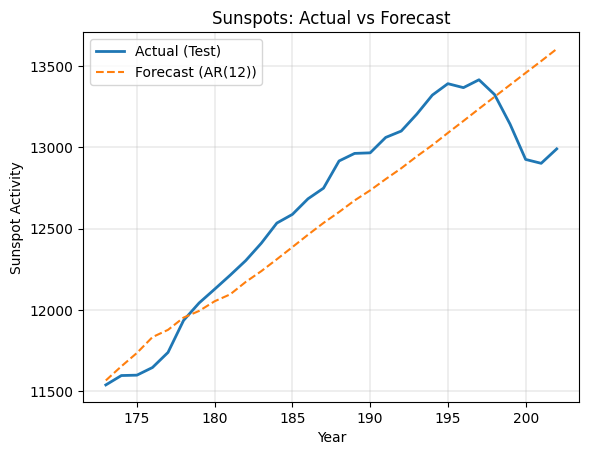

In [25]:
plt.plot(test.index,df["realgdp"].iloc[-test_horizon:],  label='Actual (Test)', linewidth=2)
plt.plot(forecast_gdp.index,    forecast_gdp.values,    label=f'Forecast (AR({p}))', linestyle='--')
plt.title('Sunspots: Actual vs Forecast')
plt.xlabel('Year')
plt.ylabel('Sunspot Activity')
plt.legend()
plt.grid(True, linewidth=0.3)
plt.show()